print("hello world ")

In [227]:
import numpy as np 
import matplotlib.pyplot as plt 
import gzip
import numpy as np
import torch 
import torch.nn.functional as F

In [228]:
print("hello world ")
import matplotlib.pyplot as plt
import gzip
import torch
BATCH = 1500
def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:      # <-- gzip.open
        data = torch.frombuffer(f.read(), dtype=torch.uint8)

    image_size = data.size(0)//(28*28)
    images = data[16:]    
    images = images[:image_size*28*28]                    # skip header
    images = images.view(image_size, 28, 28)      # reshape into images
    return images

def load_label(filename):
    with gzip.open(filename ,"rb") as f:
        data = torch.frombuffer(f.read(), dtype=torch.uint8)
    return data[8:]

train_images = load_mnist_images("train-images-idx3-ubyte.gz")
train_label = load_label("train-labels-idx1-ubyte.gz")
w1 = torch.randn(784,300,requires_grad=True)
b1 = torch.randn(300,requires_grad=True)
w2 = torch.randn(300,10 , requires_grad=True)
b2 = torch.randn(10,requires_grad=True)

hello world 


In [ ]:
loss_plot =[ ]
lr = 0.01
for i in range(1000000):
    index = torch.randint(0,len(train_images),(BATCH,))
    test = train_images[index]
    test_label = train_label[index]
    test = test.float()
    # forward

    flaten =(test.view(BATCH,-1))/225
    l1 = torch.tanh(flaten @ w1+b1 )
    logit = l1@w2+b2               # removed tanh

    loss = F.cross_entropy(logit,test_label) #one_mult.sum(dim=1).mean()         # corrected loss

    # backward
    loss.backward()

    # update
    with torch.no_grad():
        w1 -= lr * w1.grad
        b1 -= lr *b1.grad
        w2 -= lr  *w2.grad
        b2 -= lr *b2.grad

    w1.grad.zero_()
    b1.grad.zero_()
    w2.grad.zero_()
    loss_plot.append(loss.item())
    if(i%10 == 0):
     print(loss)
    # break
plt.plot(loss_plot) 


tensor(26.5576, grad_fn=<NllLossBackward0>)
tensor(22.5295, grad_fn=<NllLossBackward0>)
tensor(20.2916, grad_fn=<NllLossBackward0>)
tensor(18.6942, grad_fn=<NllLossBackward0>)
tensor(16.8474, grad_fn=<NllLossBackward0>)
tensor(15.6530, grad_fn=<NllLossBackward0>)
tensor(15.0771, grad_fn=<NllLossBackward0>)
tensor(14.4335, grad_fn=<NllLossBackward0>)
tensor(13.3102, grad_fn=<NllLossBackward0>)
tensor(13.0211, grad_fn=<NllLossBackward0>)
tensor(12.0625, grad_fn=<NllLossBackward0>)
tensor(11.5383, grad_fn=<NllLossBackward0>)
tensor(11.4473, grad_fn=<NllLossBackward0>)
tensor(11.4822, grad_fn=<NllLossBackward0>)
tensor(10.9295, grad_fn=<NllLossBackward0>)
tensor(10.7646, grad_fn=<NllLossBackward0>)
tensor(10.2642, grad_fn=<NllLossBackward0>)
tensor(9.9494, grad_fn=<NllLossBackward0>)
tensor(10.1560, grad_fn=<NllLossBackward0>)
tensor(9.9154, grad_fn=<NllLossBackward0>)
tensor(9.3722, grad_fn=<NllLossBackward0>)
tensor(9.1982, grad_fn=<NllLossBackward0>)
tensor(8.8827, grad_fn=<NllLossBackw

predicted: 3 :Actual: 3


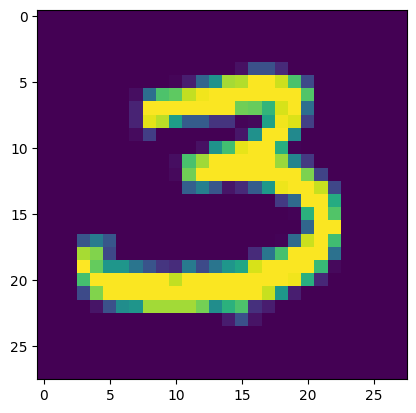

In [ ]:
train_images = load_mnist_images("t10k-images-idx3-ubyte.gz")
train_label = load_label("t10k-labels-idx1-ubyte.gz")
index = torch.randint(0,len(train_images),(1,)).squeeze().item()


test = train_images[index]
test_label = train_label[index]
test = test.float()
# forward

flaten =(test.view(1,-1))/225                   # removed tanh
l1 = torch.tanh(flaten @ w1+b1 )
logit = l1@w2+b2  
ex_logit = torch.exp(logit - logit.max())


softmax = ex_logit / ex_logit.sum()

pred  = torch.argmax(softmax,dim=1)


print("predicted:",pred.item(),":Actual:",test_label.item())
plt.imshow(test)
